In [7]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import sklearn
import xgboost
from sklearn.model_selection import RandomizedSearchCV
df = pd.read_csv(r"C:\Users\talon\Downloads\Churn_Train.csv")


In [2]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip())
churn_encode = {'No': 0, 'Yes': 1}
df['Churn'] = df['Churn'].map(churn_encode)
df['tenure'] = (df['tenure']-df['tenure'].mean())/(df['tenure'].max()-df['tenure'].min())
df['MonthlyCharges'] = (df['MonthlyCharges']-df['MonthlyCharges'].mean())/(df['MonthlyCharges'].max()-df['MonthlyCharges'].min())
df['TotalCharges'] = (df['TotalCharges']-df['TotalCharges'].mean())/(df['TotalCharges'].max()-df['TotalCharges'].min())

cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines','InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection','TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract','PaperlessBilling', 'PaymentMethod']
for cat in cat_cols:
    df[cat] = df[cat].astype('category')

# encode target, regulate numeric features, change str features to categorical

0.7975295785211949


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

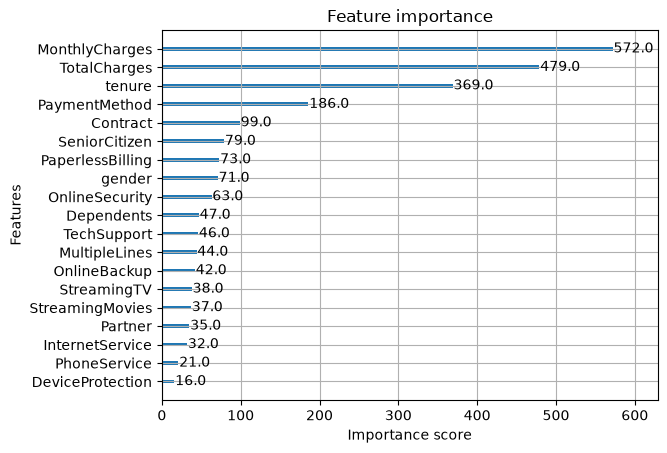

In [3]:
features = df.drop(columns = ['Churn','customerID'])
target = df['Churn']
XGB_model = xgboost.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric="logloss")
XGB_model.fit(features, target)
print(cross_val_score(XGB_model, features, target, cv=5, scoring='accuracy').mean())
xgboost.plot_importance(XGB_model)

MonthlyCharges, TotalCharges, PaymentMethod, and Contract and the 5 most important features. This is not really suprising as these features either have the largest varuety of data (not just yes or no) or are key aspects in retention (like the contract). The payment method being #4 is a little suprising as it is not something I would have expected to be important.

Train Accuracy: 0.9985800496982605
Test Accuracy: 0.7182398864442867

Train Accuracy: 0.7889598864039759
Test Accuracy: 0.7955997161107168

Train Accuracy: 0.7958821441249556
Test Accuracy: 0.794180269694819

Train Accuracy: 0.7997870074547391
Test Accuracy: 0.7998580553584103



[Text(0.5, 0.9, 'Contract_Month-to-month <= 0.5\ngini = 0.39\nsamples = 5634\nvalue = [4138, 1496]'),
 Text(0.25, 0.7, 'MonthlyCharges <= 0.288\ngini = 0.132\nsamples = 2551\nvalue = [2370, 181]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Contract_One year <= 0.5\ngini = 0.077\nsamples = 1927\nvalue = [1850, 77]'),
 Text(0.0625, 0.3, 'MonthlyCharges <= 0.149\ngini = 0.023\nsamples = 1040\nvalue = [1028, 12]'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'StreamingMovies_Yes <= 0.5\ngini = 0.136\nsamples = 887\nvalue = [822, 65]'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'Contract_Two year <= 0.5\ngini = 0.278\nsamples = 624\nvalue = [520, 104]'),
 Text(0.3125, 0.3, 'TotalCharges <= 0.655\ngini = 0.365\nsamples = 325\nvalue = [247, 78]'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, '\n  (...)  \n'),
 Text(0.4375, 0.3, 'MonthlyCharges <= 0.293\ngini = 0.159\nsampl

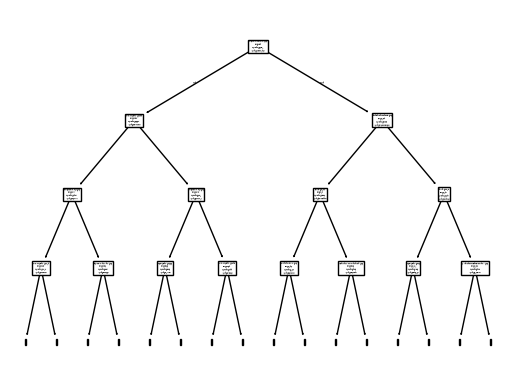

In [4]:
features = pd.get_dummies(df.drop(columns = ['Churn','customerID']))
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
DT_model = [DecisionTreeClassifier(max_depth=None),DecisionTreeClassifier(max_depth=3),DecisionTreeClassifier(max_depth=4),DecisionTreeClassifier(max_depth=5)]
for i in range(4):
    DT_model[i].fit(X_train,y_train)
    y_pred = DT_model[i].predict(X_test)
    val_accuracy = accuracy_score(y_test, y_pred)
    print('Train Accuracy:', DT_model[i].score(X_train, y_train))
    print('Test Accuracy:',val_accuracy)
    print()
sklearn.tree.plot_tree(DT_model[3], feature_names= features.columns, max_depth=3)


While not restricting the tree to a max depth maximizes the training accuracy score, it is extremely overfit and does not do well on the test set. In contrast restricting it to a depth of 5 ensures a high accuracy for the training and test set.

In [5]:
Forest_model = sklearn.ensemble.RandomForestClassifier(n_estimators=50, random_state=42)
Forest_model.fit(X_train, y_train)
print('cv with all features:',cross_val_score(Forest_model, X_train, y_train, cv=5, scoring='accuracy').mean())

lowest_columns = pd.Series(Forest_model.feature_importances_, index=features.columns).sort_values(ascending=True).head(10).index
X_train2 = X_train.drop(columns=lowest_columns)
print('cv with only important features:',cross_val_score(Forest_model, X_train2, y_train, cv=5, scoring='accuracy').mean())


cv with all features: 0.7854093216559155
cv with only important features: 0.7868290199700236


The cv score seems to plateau above n_estimators = 50. However, above 50, the cv with all features actually has a better score then with only important features. Under 50, the cv score is better with only the important features.

[0]	validation_0-logloss:0.54886
[1]	validation_0-logloss:0.52579
[2]	validation_0-logloss:0.50753
[3]	validation_0-logloss:0.49218
[4]	validation_0-logloss:0.47874
[5]	validation_0-logloss:0.46827
[6]	validation_0-logloss:0.45897
[7]	validation_0-logloss:0.45117
[8]	validation_0-logloss:0.44366
[9]	validation_0-logloss:0.43757
[10]	validation_0-logloss:0.43274
[11]	validation_0-logloss:0.42821
[12]	validation_0-logloss:0.42435
[13]	validation_0-logloss:0.42105
[14]	validation_0-logloss:0.41770
[15]	validation_0-logloss:0.41514
[16]	validation_0-logloss:0.41312
[17]	validation_0-logloss:0.41092
[18]	validation_0-logloss:0.40925
[19]	validation_0-logloss:0.40775
[20]	validation_0-logloss:0.40631
[21]	validation_0-logloss:0.40557
[22]	validation_0-logloss:0.40481
[23]	validation_0-logloss:0.40397
[24]	validation_0-logloss:0.40338
[25]	validation_0-logloss:0.40264
[26]	validation_0-logloss:0.40217
[27]	validation_0-logloss:0.40121
[28]	validation_0-logloss:0.40072
[29]	validation_0-loglos

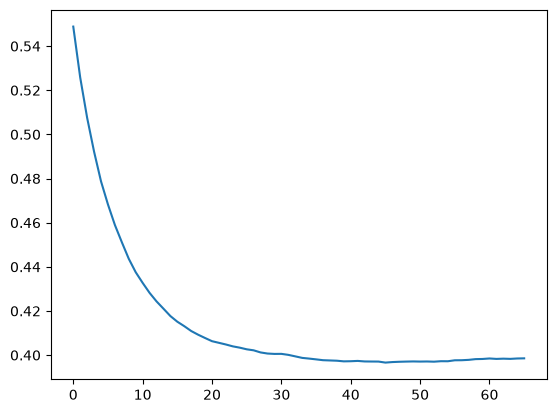

In [11]:
XGB_model2 = xgboost.XGBClassifier(n_estimators=100, learning_rate=.1, max_depth=5, eval_metric="logloss", early_stopping_rounds=20)
XGB_model2.fit(X_train, y_train,eval_set=[(X_test, y_test)])
print(XGB_model2.best_iteration)
results = XGB_model2.evals_result()
plt.plot(results["validation_0"]["logloss"])
y_pred3 = XGB_model2.predict(X_test)
val_accuracy3 = accuracy_score(y_test, y_pred3)
print(val_accuracy3)

In [ ]:
params = {"max_depth": [3,4,5,6], "learning_rate": [0.01,0.05,0.1,0.2], "n_estimators": [100,200,300], "subsample": [0.7,0.8,0.9,1.0], "colsample_bytree": [0.7,0.8,0.9,1.0]}
search = RandomizedSearchCV(XGB_model2, params, n_iter=30, cv=5, scoring="accuracy", random_state=42, n_jobs=-1)
search.fit(X_train, y_train,eval_set=[(X_test, y_test)])

tuned_XGB = xgboost.XGBClassifier(n_estimators=300, learning_rate=.01, max_depth=4, eval_metric="logloss", early_stopping_rounds=20, colsample_bytree = .8, subsample=.8)
tuned_XGB.fit(X_train, y_train,eval_set=[(X_test, y_test)])
y_pred4 = tuned_XGB.predict(X_test)
val_accuracy4 = accuracy_score(y_test, y_pred4)

print(search.best_params_)
print(val_accuracy4)

[0]	validation_0-logloss:0.57498
[1]	validation_0-logloss:0.57230
[2]	validation_0-logloss:0.56951
[3]	validation_0-logloss:0.56685
[4]	validation_0-logloss:0.56426
[5]	validation_0-logloss:0.56161
[6]	validation_0-logloss:0.55918
[7]	validation_0-logloss:0.55660
[8]	validation_0-logloss:0.55413
[9]	validation_0-logloss:0.55166
[10]	validation_0-logloss:0.54946
[11]	validation_0-logloss:0.54705
[12]	validation_0-logloss:0.54486
[13]	validation_0-logloss:0.54261
[14]	validation_0-logloss:0.54039
[15]	validation_0-logloss:0.53820
[16]	validation_0-logloss:0.53615
[17]	validation_0-logloss:0.53421
[18]	validation_0-logloss:0.53219
[19]	validation_0-logloss:0.53019
[20]	validation_0-logloss:0.52828
[21]	validation_0-logloss:0.52642
[22]	validation_0-logloss:0.52460
[23]	validation_0-logloss:0.52280
[24]	validation_0-logloss:0.52105
[25]	validation_0-logloss:0.51938
[26]	validation_0-logloss:0.51796
[27]	validation_0-logloss:0.51646
[28]	validation_0-logloss:0.51474
[29]	validation_0-loglos

Interstingly, the model tuned by randomized search actually did noticably worse. This is likely because of having too many parameters to test, resulting in the search not finding the best parameters out of those given. For future models, first testing the which hyperparameters are the most important, then finding the range of reasonable values for those hyperparameters would be a much better strategy.